Purpose: Finalize XGBoost code in Python before moving to the HPC.<br>
Author: Anna Pardo<br>
Date initiated: Feb. 17, 2026

In [14]:
from xgboost import XGBRegressor
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn import metrics
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.metrics import PredictionErrorDisplay
from sklearn.metrics import mean_squared_error
import random
import scipy

In [15]:
# load data (CAM genes as features)
camfeatures = pd.read_csv("./CAMgenes_logTPM_phys_forxgboost.txt",sep="\t",header="infer")
camfeatures.head()

,sample_name,genotype,treat,ZT,photo,cond,Yucal.01G077800.v2.1,Yucal.01G137500.v2.1,Yucal.01G165600.v2.1,Yucal.02G112700.v2.1,...,YufilH1069008m.g,YufilH1069011m.g,YufilH1069012m.g,YufilH1072272m.g,YufilH1072277m.g,YufilH1075687m.g,YufilH1082305m.g,YufilH1082501m.g,YufilH1086337m.g,YufilH1086489m.g
0,Y111,18,D,1.0,2.627596,0.026132,5.207348,1.985238,9.233768,8.540209,...,5.908476,0.0,0.0,0.0,4.795117,0.000000,3.197020,1.091027,0.293100,0.860700
1,Y123,18,D,1.0,2.679172,0.021603,4.552644,1.349067,9.081378,7.905170,...,5.902871,0.0,0.0,0.0,4.969240,0.341290,2.639020,1.089835,0.191078,0.387094
2,Y120,18,D,3.0,1.211527,0.007856,4.965965,2.080715,10.231111,10.600430,...,5.799164,0.0,0.0,0.0,4.598032,0.229951,2.514945,2.464440,0.315569,0.244272
3,Y125,18,D,3.0,1.289725,0.009783,5.374245,1.907274,9.716797,9.205871,...,5.965906,0.0,0.0,0.0,4.768673,0.311715,2.733348,2.796774,0.468769,0.300723
4,Y129,18,D,3.0,1.549238,0.010471,5.471138,2.077216,9.946447,9.425045,...,5.796786,0.0,0.0,0.0,4.731755,0.167593,2.746976,2.377347,0.134937,0.395782


In [3]:
# get metadata from camfeatures
md = camfeatures[["sample_name","genotype","treat","ZT"]]
md.head()

,sample_name,genotype,treat,ZT
0,Y111,18,D,1.0
1,Y123,18,D,1.0
2,Y120,18,D,3.0
3,Y125,18,D,3.0
4,Y129,18,D,3.0


In [4]:
counts = md.groupby("genotype").count().reset_index()[["genotype","sample_name"]].rename(columns={"sample_name":"sampcount"})

In [14]:
counts.head()

,genotype,sampcount
0,13,12
1,15,4
2,18,34
3,19,13
4,1AB,33


In [5]:
counts["percent"] = (counts["sampcount"]/len(md.index))*100
counts.head()

,genotype,sampcount,percent
0,13,12,5.769231
1,15,4,1.923077
2,18,34,16.346154
3,19,13,6.250000
4,1AB,33,15.865385


In [6]:
counts[counts["genotype"]=="13"].percent.item()

5.769230769230769

In [7]:
# set up a function to pull random genotypes until the test data represent 15-25% of the total data
def genotype_split_selection(pctdf,minval=15,maxval=25):
    p=0
    gtselec = []
    while p<minval:
        gt = random.choice(list(pctdf["genotype"]))
        pct = pctdf[pctdf["genotype"]==gt].percent.item()
        p = p+pct
        if p<maxval:
            gtselec.append(gt)
            pctdf = pctdf[pctdf["genotype"]!=gt]
        else:
            p = p-pct
    print("Test percentage: ",str(p))
    return gtselec

In [8]:
# do a sample train-test split
testgts = genotype_split_selection(counts)

Test percentage:  24.03846153846154


In [9]:
testgts

['45', '15', '2AB']

In [10]:
# define a function to get a sample list for the TEST data
def test_samps(meta,pctdf,minval=15,maxval=25):
    gtlist = genotype_split_selection(pctdf,minval,maxval)
    subdf = meta[meta["genotype"].isin(gtlist)]
    return {"test_genotypes":gtlist,"sample_ids":list(subdf["sample_name"])}

In [11]:
testinfo = test_samps(md,counts)
testinfo["test_genotypes"]

Test percentage:  18.26923076923077


['52', '56', '15', '13']

In [28]:
camfeatures.head()

,sample_name,genotype,treat,ZT,photo,cond,Yucal.01G077800.v2.1,Yucal.01G137500.v2.1,Yucal.01G165600.v2.1,Yucal.02G112700.v2.1,...,YufilH1069008m.g,YufilH1069011m.g,YufilH1069012m.g,YufilH1072272m.g,YufilH1072277m.g,YufilH1075687m.g,YufilH1082305m.g,YufilH1082501m.g,YufilH1086337m.g,YufilH1086489m.g
0,Y111,18,D,1.0,2.627596,0.026132,5.207348,1.985238,9.233768,8.540209,...,5.908476,0.0,0.0,0.0,4.795117,0.000000,3.197020,1.091027,0.293100,0.860700
1,Y123,18,D,1.0,2.679172,0.021603,4.552644,1.349067,9.081378,7.905170,...,5.902871,0.0,0.0,0.0,4.969240,0.341290,2.639020,1.089835,0.191078,0.387094
2,Y120,18,D,3.0,1.211527,0.007856,4.965965,2.080715,10.231111,10.600430,...,5.799164,0.0,0.0,0.0,4.598032,0.229951,2.514945,2.464440,0.315569,0.244272
3,Y125,18,D,3.0,1.289725,0.009783,5.374245,1.907274,9.716797,9.205871,...,5.965906,0.0,0.0,0.0,4.768673,0.311715,2.733348,2.796774,0.468769,0.300723
4,Y129,18,D,3.0,1.549238,0.010471,5.471138,2.077216,9.946447,9.425045,...,5.796786,0.0,0.0,0.0,4.731755,0.167593,2.746976,2.377347,0.134937,0.395782


In [12]:
# for input logTPM data: drop metadata & set sample name as index
logtpm = camfeatures.set_index("sample_name").drop(["genotype","treat","ZT","photo","cond"],axis=1)
logtpm.head()

,Yucal.01G077800.v2.1,Yucal.01G137500.v2.1,Yucal.01G165600.v2.1,Yucal.02G112700.v2.1,Yucal.02G133400.v2.1,Yucal.03G000600.v2.1,Yucal.03G005000.v2.1,Yucal.03G079400.v2.1,Yucal.03G120900.v2.1,Yucal.03G190000.v2.1,...,YufilH1069008m.g,YufilH1069011m.g,YufilH1069012m.g,YufilH1072272m.g,YufilH1072277m.g,YufilH1075687m.g,YufilH1082305m.g,YufilH1082501m.g,YufilH1086337m.g,YufilH1086489m.g
sample_name,,,,,,,,,,,,,,,,,,,,,
Y111,5.207348,1.985238,9.233768,8.540209,7.589815,5.488031,1.363338,6.453254,4.842402,0.439765,...,5.908476,0.0,0.0,0.0,4.795117,0.000000,3.197020,1.091027,0.293100,0.860700
Y123,4.552644,1.349067,9.081378,7.905170,6.935186,4.646011,2.714060,6.119254,4.617896,0.620771,...,5.902871,0.0,0.0,0.0,4.969240,0.341290,2.639020,1.089835,0.191078,0.387094
Y120,4.965965,2.080715,10.231111,10.600430,7.493226,4.828845,1.864187,6.516083,3.092389,0.195415,...,5.799164,0.0,0.0,0.0,4.598032,0.229951,2.514945,2.464440,0.315569,0.244272
Y125,5.374245,1.907274,9.716797,9.205871,7.430557,5.175657,2.508658,6.660938,3.912309,0.814943,...,5.965906,0.0,0.0,0.0,4.768673,0.311715,2.733348,2.796774,0.468769,0.300723
Y129,5.471138,2.077216,9.946447,9.425045,7.525505,4.926015,2.446109,6.427171,3.569423,0.301779,...,5.796786,0.0,0.0,0.0,4.731755,0.167593,2.746976,2.377347,0.134937,0.395782


In [13]:
# get just physiology data (in this case, let's model with stomatal conductance as our y variable)
cond = camfeatures[["sample_name","cond"]].set_index("sample_name")
cond.head()

,cond
sample_name,
Y111,0.026132
Y123,0.021603
Y120,0.007856
Y125,0.009783
Y129,0.010471


In [43]:
# split train & test: X
X_train = logtpm[~logtpm.index.isin(testinfo["sample_ids"])]
X_test = logtpm[logtpm.index.isin(testinfo["sample_ids"])]
X_test.head()

,Yucal.01G077800.v2.1,Yucal.01G137500.v2.1,Yucal.01G165600.v2.1,Yucal.02G112700.v2.1,Yucal.02G133400.v2.1,Yucal.03G000600.v2.1,Yucal.03G005000.v2.1,Yucal.03G079400.v2.1,Yucal.03G120900.v2.1,Yucal.03G190000.v2.1,...,YufilH1069008m.g,YufilH1069011m.g,YufilH1069012m.g,YufilH1072272m.g,YufilH1072277m.g,YufilH1075687m.g,YufilH1082305m.g,YufilH1082501m.g,YufilH1086337m.g,YufilH1086489m.g
sample_name,,,,,,,,,,,,,,,,,,,,,
Y312,3.972244,1.524613,10.091663,10.601655,6.672510,5.669318,1.027213,6.462015,3.211861,0.488758,...,5.819243,0.0,0.0,0.0,4.781455,0.279165,2.098849,0.809221,0.117645,0.661080
Y314,4.620306,2.173177,9.989126,10.879403,7.063257,5.072301,2.571870,6.458542,4.561105,0.416332,...,6.063356,0.0,0.0,0.0,5.024502,0.339906,2.799018,0.677283,0.420436,0.095018
Y316,4.406494,1.940664,9.654117,9.851844,7.465419,4.088409,2.984632,6.890712,3.973834,0.000000,...,5.922804,0.0,0.0,0.0,4.654832,0.582811,2.832851,2.505168,0.000000,0.563960
Y329,4.016545,1.521259,9.591629,10.039760,7.700982,3.761855,2.084062,6.711529,3.190784,0.166535,...,6.077807,0.0,0.0,0.0,4.669869,0.133792,2.348498,2.259807,0.207502,0.208680
Y330,4.646478,1.524733,9.120149,9.939099,7.657880,4.751010,3.761931,6.940729,2.586100,0.194302,...,6.224215,0.0,0.0,0.0,5.044659,0.000000,2.922876,0.595526,0.241549,0.329665


In [45]:
# split train & test: y
y_train = cond[~cond.index.isin(testinfo["sample_ids"])]["cond"]
y_test = cond[cond.index.isin(testinfo["sample_ids"])]["cond"]
y_train.head()

sample_name
Y111    0.026132
Y123    0.021603
Y120    0.007856
Y125    0.009783
Y129    0.010471
Name: cond, dtype: float64

In [47]:
# split the training set for cross-validation: 25%
## set up a function to do this
def split_train_val(trainx,trainy,testgts,minval=15,maxval=25,meta=md):
    submd = meta[~meta["genotype"].isin(testgts)]
    traincounts = submd.groupby("genotype").count().reset_index()[["genotype","sample_name"]]
    traincounts["percent"] = (traincounts["sample_name"]/len(submd.index))*100
    cvinfo = test_samps(submd,traincounts,minval,maxval)
    
    valx = trainx[~trainx.index.isin(cvinfo["sample_ids"])]
    tx = trainx[trainx.index.isin(cvinfo["sample_ids"])]
    
    valy = trainy[~trainy.index.isin(cvinfo["sample_ids"])]
    ty = trainy[trainy.index.isin(cvinfo["sample_ids"])]
    
    return tx,valx,ty,valy

In [48]:
xtrain,xval,ytrain,yval = split_train_val(X_train,y_train,testinfo["test_genotypes"])

Test percentage:  19.760479041916167


In [52]:
# following this tutorial: https://macalusojeff.github.io/post/HyperparameterTuningXGB/
# Training a baseline model with the default parameters to see if we can improve on the results
baseline_model = XGBRegressor(n_jobs=-1, random_state=46)
baseline_model.fit(xtrain, ytrain)
print("Baseline model -")
print("R^2: ", baseline_model.score(X_test, y_test))
print("MSE: ", mean_squared_error(y_test, baseline_model.predict(X_test)))

Baseline model -
R^2:  0.1837157693913506
MSE:  0.00011215572158419397


In [55]:
# early stopping example from tutorial
import time

start_time = time.time()
baseline_model.fit(xtrain, ytrain)
print("Training time for baseline model: ", time.time() - start_time)

early_stopping_model = XGBRegressor(early_stopping_rounds=5, n_jobs=-1, random_state=46)
start_time = time.time()
early_stopping_model.fit(xtrain, ytrain, eval_set=[(xval, yval)], verbose=False)
print("Training time for early stopping model: ", time.time() - start_time)
print("Early stopping model -")
print("Stopped on iteration: ", early_stopping_model.best_iteration)
print("R^2: ", early_stopping_model.score(X_test, y_test))
print("MSE: ", mean_squared_error(y_test, early_stopping_model.predict(X_test)))


Training time for baseline model:  0.06341552734375
Training time for early stopping model:  0.04343295097351074
Early stopping model -
Stopped on iteration:  0
R^2:  0.003691180317802023
MSE:  0.00013689071821078186


In [57]:
# tutorial code: run hyperparameter tuning manually
from sklearn.base import clone
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
#from tqdm import tqdm



In [66]:
# Use train/val/test split or k-folds cross validation
tune_with_kfolds = False

# Define the parameter distributions for hyperparameter tuning
# Using this guide: https://machinelearningmastery.com/configure-gradient-boosting-algorithm/
# Parameter documentation: https://xgboost.readthedocs.io/en/stable/parameter.html
param_distributions = {
    "learning_rate": scipy.stats.uniform(loc=0.003, scale=0.19),  # Default is 0.3. Ranges from loc to loc+scale.
    "subsample": scipy.stats.uniform(loc=0.5, scale=0.5),  # Default is 1
    "colsample_bytree": scipy.stats.uniform(loc=0.5, scale=0.5),  # Default is 1
    "min_child_weight": [1, 3, 5, 7],  # Default is 1
    "max_depth": np.append(0, np.arange(3, 16)),  # Default is 6
    "alpha": [0, 0.01, 1, 2, 5, 7, 10, 50, 100],  # Default is 0. AKA reg_alpha.
    "lambda": [0, 0.01, 1, 5, 10, 20, 50, 100]  # Default is 0. AKA reg_lambda.
}



In [61]:
def sample_from_param_distributions(param_distributions: dict) -> dict:
    """
    Sample a value from each parameter distribution defined in param_distributions.

    Parameters:
    - param_distributions (dict): Dictionary where keys are parameter names and values are either:
        - scipy.stats distribution objects for continuous distributions.
        - Lists or numpy arrays for discrete choices.

    Returns:
    - sampled_values (dict): Dictionary containing sampled values corresponding to each parameter.
    """
    sampled_values = {}
    for param, distribution in param_distributions.items():
        if isinstance(distribution, scipy.stats._distn_infrastructure.rv_frozen):
            sampled_values[param] = distribution.rvs()
        elif isinstance(distribution, list) or isinstance(distribution, np.ndarray):
            sampled_values[param] = np.random.choice(distribution)
        else:
            raise ValueError(f"Unsupported distribution type for parameter '{param}'")

    return sampled_values




In [67]:
num_iterations = 40
optimal_params = {}
best_score = -np.inf
for iteration in range(num_iterations):
    # Sample values from the distributions
    sampled_params = sample_from_param_distributions(param_distributions)

    # Train the model, get the performance on the validation set
    model = XGBRegressor(n_estimators=10000, early_stopping_rounds=20,
                             n_jobs=-1, random_state=46, **sampled_params)

    # Perform the tuning with either k-folds or train/test split
    # I don't want k-folds because of data leakage potential
    if tune_with_kfolds == True:
        cv = KFold(n_splits=3, shuffle=True, random_state=46)  # Use StratifiedKFold for classification
        cv_results = []
        for train_idx, val_idx in cv.split(xtrain, ytrain):
            print(train_idx)
            print(val_idx)
            X_train_fold, X_val_fold = xtrain[train_idx], xtrain[val_idx]
            y_train_fold, y_val_fold = ytrain[train_idx], ytrain[val_idx]

            model_clone = clone(model)
            model_clone.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)], verbose=False)
            predictions = model_clone.predict(X_val_fold)
            fold_neg_mse = -mean_squared_error(y_true=y_val_fold, y_pred=predictions)
            cv_results.append(fold_neg_mse)

        neg_mean_squared_error = np.mean(cv_results)
    else:
        # Train/test split with the validation data set for early stopping
        model.fit(xtrain, ytrain, eval_set=[(xval, yval)], verbose=False)
        predictions = model.predict(xval)
        neg_mean_squared_error = -mean_squared_error(y_true=yval, y_pred=predictions)

    # Set the optimal parameters if the performance is better
    if neg_mean_squared_error > best_score:
        best_score = neg_mean_squared_error
        optimal_params = sampled_params
        # Need to re-train w/ early stopping to get optimal number of estimators if tuned with k-folds
        if tune_with_kfolds == False:
            optimal_params["n_estimators"] = model.best_iteration



In [68]:
# Re-train with the optimal hyperparams
# Re-perform early stopping if k-folds was used for tuning
if tune_with_kfolds == True:
    tuned_model = xgb.XGBRegressor(**optimal_params, n_jobs=-1, random_state=46,
                                   n_estimators=10000, early_stopping_rounds=20)
    tuned_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    optimal_params["n_estimators"] = tuned_model.best_iteration
else:
    tuned_model = XGBRegressor(**optimal_params, n_jobs=-1, random_state=46)
    tuned_model.fit(xtrain, ytrain)

# Report the results
print("Tuned model -")
print("R^2: ", tuned_model.score(X_test, y_test))
print("MSE: ", mean_squared_error(y_test, tuned_model.predict(X_test)))


Tuned model -
R^2:  0.07298816026222654
MSE:  0.0001273694601760931


In [69]:
# optimize this code for my needs
## exclude k-fold cross-validation

# suggested param distributions from 
## https://xgboosting.com/suggested-ranges-for-tuning-xgboost-hyperparameters/?utm_source=chatgpt.com
pdist2 = {
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'learning_rate': [0.01, 0.05, 0.1, 0.2]
}

In [70]:
param_distributions

{'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x75f95c7af580>,
 'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x75f95c7af130>,
 'colsample_bytree': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x75f95c7aff40>,
 'min_child_weight': [1, 3, 5, 7],
 'max_depth': array([ 0,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
 'alpha': [0, 0.01, 1, 2, 5, 7, 10, 50, 100],
 'lambda': [0, 0.01, 1, 5, 10, 20, 50, 100]}

In [71]:
# I am going to go with param_distributions to start with since it seems to be inclusive of pdist2.
# set up a function for identification of optimal hyperparameters

def opt_hyperparams(niter,nestim,estop,trainx,trainy,valx,valy):
    optimal_params = {}
    best_score = -np.inf
    for iteration in range(niter):
        # Sample values from the distributions
        sampled_params = sample_from_param_distributions(param_distributions)

        # Train the model, get the performance on the validation set
        model = XGBRegressor(n_estimators=nestim, early_stopping_rounds=estop,
                                 n_jobs=-1, random_state=46, **sampled_params)

        # Perform the tuning with train/test split
        # I don't want k-folds because of data leakage potential
        # Train/test split with the validation data set for early stopping
        model.fit(trainx, trainy, eval_set=[(valx, valy)], verbose=False)
        predictions = model.predict(valx)
        neg_mean_squared_error = -mean_squared_error(y_true=valy, y_pred=predictions)

        # Set the optimal parameters if the performance is better
        if neg_mean_squared_error > best_score:
            best_score = neg_mean_squared_error
            optimal_params = sampled_params
            
    print("Best score (negative MSE): ",str(best_score))
    return optimal_params

In [73]:
def retrain_optparams(optimal_params,trainx,trainy):
    tuned_model = XGBRegressor(**optimal_params, n_jobs=-1, random_state=46)
    tuned_model.fit(trainx, trainy)

    return tuned_model

In [87]:
# try to get the model on CAM genes to work better
cam_params = opt_hyperparams(500,10000,250,xtrain,ytrain,xval,yval)

Best score (negative MSE):  -5.4042864155031294e-05


In [88]:
camtuned = retrain_optparams(cam_params,xtrain,ytrain)

In [89]:
cam_params

{'learning_rate': 0.010424285391581935,
 'subsample': 0.9728139418741042,
 'colsample_bytree': 0.8617241724623108,
 'min_child_weight': 1,
 'max_depth': 12,
 'alpha': 0.0,
 'lambda': 0.01}

In [90]:
# Report the results
print("Tuned model -")
print("R^2: ", camtuned.score(X_test, y_test))
print("MSE: ", mean_squared_error(y_test, camtuned.predict(X_test)))

Tuned model -
R^2:  0.030747712538133354
MSE:  0.00013317320808263128


In [91]:
preds = camtuned.predict(X_test)

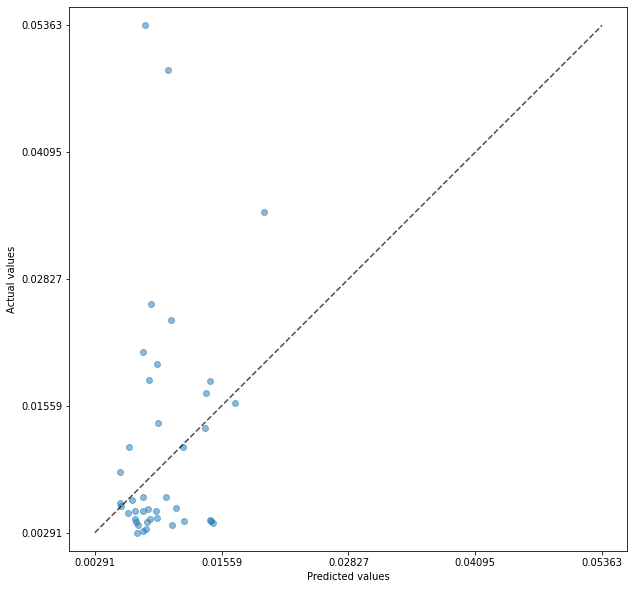

In [92]:
# plot predicted vs. actual Y values
fig,ax = plt.subplots(figsize=(10,10))
PredictionErrorDisplay.from_predictions(
    y_test,
    preds,
    kind="actual_vs_predicted",
    ax=ax,
    scatter_kwargs={"alpha": 0.5},
)

In [ ]:
# could I be getting data leakage by training on genotypes from multiple physiological categories? or is ignoring categories
## in favor of predicting a spectrum of quantitative variation what this is all about?

# find what percentage of the data each physiological category makes up, overall
## also rank genotypes by each physiological marker
### also! try predictiong photo instead of cond - might work better? or might work worse, who knows!
# and try looping through all the sets-of-genotypes and using all of them as test data